# 05 — Baseline Modeling

**Goal:** Establish baseline performance with default hyperparameters before tuning.

**Split:** Train on 2015 → mid-2025, test on mid-2025 → 2026.
- ~5,000 training fights, ~400+ test fights
- Test set is pure out-of-time: the model never sees any 2025H2/2026 data during training or CV

**Models:** XGBoost, LightGBM, CatBoost (conservative defaults), plus average ensemble.

**Evaluation:**
- Accuracy, AUC, log loss, Brier score
- Feature importance (per-model + consensus)
- Ablation study (which feature groups matter?)
- Calibration analysis
- Error analysis (where does the model fail?)

In [2]:
import pandas as pd
import numpy as np
import json, os, warnings
from pathlib import Path

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, log_loss, roc_auc_score,
                             brier_score_loss, classification_report,
                             confusion_matrix)
from sklearn.calibration import calibration_curve

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# Auto-detect data path
DATA = Path('./data') if Path('./data/model_data.csv').exists() else Path('../data')
MODEL_DIR = Path('../models') if not Path('./models').exists() else Path('./models')
MODEL_DIR.mkdir(exist_ok=True)

print(f"Data path:  {DATA.resolve()}")
print(f"Model path: {MODEL_DIR.resolve()}")

df = pd.read_csv(DATA / 'model_data.csv', parse_dates=['event_date'])
df = df.sort_values('event_date').reset_index(drop=True)

print(f"Loaded: {df.shape[0]:,} fights × {df.shape[1]} columns")
print(f"Date range: {df['event_date'].min().date()} → {df['event_date'].max().date()}")
print(f"Overall red win rate: {df['f1_win'].mean():.3f}")

Data path:  /workspaces/UFCML/notebooks/data
Model path: /workspaces/UFCML/models
Loaded: 5,485 fights × 322 columns
Date range: 2015-01-03 → 2026-04-11
Overall red win rate: 0.571


## Feature Selection & Temporal Split

Drop identity/target/post-fight columns. Split at mid-2025 so the test set
covers the most recent ~9 months of fights.

In [3]:
target = 'f1_win'

# Columns to exclude from features
drop_cols = [
    'event_name', 'event_date', 'fight_url', 'fighter_1', 'fighter_2',
    'winner', 'weight_class', 'round', 'time', 'method_clean', 'finish_type',
    'f1_win', 'stance_matchup', 'f1_stance', 'f2_stance'
]

feature_cols = sorted([c for c in df.columns if c not in drop_cols])
print(f"Features: {len(feature_cols)}")

# ── Temporal split ──
SPLIT_DATE = '2025-07-01'

train_mask = df['event_date'] < SPLIT_DATE
test_mask  = df['event_date'] >= SPLIT_DATE

# Show actual event boundary
last_train = df.loc[train_mask, 'event_date'].max()
first_test = df.loc[test_mask, 'event_date'].min()
print(f"\nSplit boundary: last train event {last_train.date()} | first test event {first_test.date()}")

X_train = df.loc[train_mask, feature_cols]
y_train = df.loc[train_mask, target]
X_test  = df.loc[test_mask, feature_cols]
y_test  = df.loc[test_mask, target]

baseline_acc = y_test.mean()
baseline_ll  = log_loss(y_test, np.full(len(y_test), y_train.mean()))

print(f"\nTrain: {len(X_train):,} fights  ({df.loc[train_mask, 'event_date'].min().date()} → {last_train.date()})")
print(f"Test:  {len(X_test):,} fights  ({first_test.date()} → {df.loc[test_mask, 'event_date'].max().date()})")
print(f"\nTest baseline (always pick red): {baseline_acc:.3f}")
print(f"Test baseline log loss:           {baseline_ll:.3f}")

# Test set composition
print(f"\nTest fights by year-month:")
monthly = df.loc[test_mask].groupby(df.loc[test_mask, 'event_date'].dt.to_period('M')).size()
for period, count in monthly.items():
    print(f"  {period}: {count} fights")

Features: 310

Split boundary: last train event 2025-06-28 | first test event 2025-07-12

Train: 5,093 fights  (2015-01-03 → 2025-06-28)
Test:  392 fights  (2025-07-12 → 2026-04-11)

Test baseline (always pick red): 0.554
Test baseline log loss:           0.688

Test fights by year-month:
  2025-07: 38 fights
  2025-08: 50 fights
  2025-09: 38 fights
  2025-10: 51 fights
  2025-11: 53 fights
  2025-12: 24 fights
  2026-01: 24 fights
  2026-02: 39 fights
  2026-03: 51 fights
  2026-04: 24 fights


## Cross-Validation Utility

5-fold TimeSeriesSplit on training data. Returns per-fold and aggregate metrics.

In [4]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
cv_splits = list(tscv.split(X_train))

print(f"TimeSeriesSplit: {N_SPLITS} folds")
for i, (tr_idx, val_idx) in enumerate(cv_splits):
    val_dates = df.loc[train_mask].iloc[val_idx]['event_date']
    print(f"  Fold {i+1}: train {len(tr_idx):,} → val {len(val_idx):,}  "
          f"({val_dates.min().date()} → {val_dates.max().date()})")


def evaluate_cv(model_class, params, name="Model"):
    """Run TimeSeriesSplit CV + final test evaluation."""
    fold_results = []

    for i, (tr_idx, val_idx) in enumerate(cv_splits):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = model_class(**params)
        model.fit(X_tr, y_tr)

        y_prob = model.predict_proba(X_val)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        fold_results.append({
            'fold': i + 1,
            'acc':   accuracy_score(y_val, y_pred),
            'auc':   roc_auc_score(y_val, y_prob),
            'll':    log_loss(y_val, y_prob),
            'brier': brier_score_loss(y_val, y_prob),
            'n_val': len(y_val),
        })

    cv_df = pd.DataFrame(fold_results)

    # Print CV results
    print(f"\n{'─'*60}")
    print(f"{name} — Cross-Validation")
    print(f"{'─'*60}")
    for _, row in cv_df.iterrows():
        print(f"  Fold {row['fold']:.0f}: acc={row['acc']:.3f}  auc={row['auc']:.3f}  "
              f"ll={row['ll']:.3f}  (n={row['n_val']:.0f})")
    print(f"  {'Mean':>7s}: acc={cv_df['acc'].mean():.3f}  auc={cv_df['auc'].mean():.3f}  "
          f"ll={cv_df['ll'].mean():.3f}  brier={cv_df['brier'].mean():.3f}")

    # Train on full training set, evaluate on test
    final_model = model_class(**params)
    final_model.fit(X_train, y_train)

    y_prob_test = final_model.predict_proba(X_test)[:, 1]
    y_pred_test = (y_prob_test >= 0.5).astype(int)

    test_metrics = {
        'acc':   accuracy_score(y_test, y_pred_test),
        'auc':   roc_auc_score(y_test, y_prob_test),
        'll':    log_loss(y_test, y_prob_test),
        'brier': brier_score_loss(y_test, y_pred_test),
    }

    print(f"\n  Test:    acc={test_metrics['acc']:.3f}  auc={test_metrics['auc']:.3f}  "
          f"ll={test_metrics['ll']:.3f}  brier={test_metrics['brier']:.3f}")
    print(f"  Lift:    +{test_metrics['acc'] - baseline_acc:.3f} vs always-red")

    return {
        'model': final_model,
        'cv': cv_df,
        'test': test_metrics,
        'y_prob': y_prob_test,
        'y_pred': y_pred_test,
    }

print("\n✅ evaluate_cv() ready")

TimeSeriesSplit: 5 folds
  Fold 1: train 853 → val 848  (2016-11-19 → 2018-09-08)
  Fold 2: train 1,701 → val 848  (2018-09-08 → 2020-07-11)
  Fold 3: train 2,549 → val 848  (2020-07-11 → 2022-03-12)
  Fold 4: train 3,397 → val 848  (2022-03-12 → 2023-10-21)
  Fold 5: train 4,245 → val 848  (2023-10-21 → 2025-06-28)

✅ evaluate_cv() ready


## XGBoost (Default Hyperparameters)

In [5]:
xgb_params = {
    'n_estimators': 500,
    'max_depth': 5,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0,
}

xgb_results = evaluate_cv(XGBClassifier, xgb_params, "XGBoost")

KeyboardInterrupt: 

## LightGBM (Default Hyperparameters)

In [ ]:
lgb_params = {
    'n_estimators': 500,
    'max_depth': 5,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'num_leaves': 31,
    'min_child_samples': 20,
    'metric': 'binary_logloss',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
}

lgb_results = evaluate_cv(LGBMClassifier, lgb_params, "LightGBM")


────────────────────────────────────────────────────────────
LightGBM — Cross-Validation
────────────────────────────────────────────────────────────
  Fold 1: acc=0.647  auc=0.707  ll=0.764  (n=848)
  Fold 2: acc=0.666  auc=0.720  ll=0.661  (n=848)
  Fold 3: acc=0.659  auc=0.707  ll=0.658  (n=848)
  Fold 4: acc=0.735  auc=0.808  ll=0.529  (n=848)
  Fold 5: acc=0.730  auc=0.805  ll=0.547  (n=848)
     Mean: acc=0.688  auc=0.749  ll=0.632  brier=0.211

  Test:    acc=0.781  auc=0.868  ll=0.452  brier=0.219
  Lift:    +0.227 vs always-red


## CatBoost (Default Hyperparameters)

In [ ]:
cat_params = {
    'iterations': 500,
    'depth': 5,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'l2_leaf_reg': 3.0,
    'eval_metric': 'Logloss',
    'random_seed': 42,
    'verbose': 0,
}

cat_results = evaluate_cv(CatBoostClassifier, cat_params, "CatBoost")


────────────────────────────────────────────────────────────
CatBoost — Cross-Validation
────────────────────────────────────────────────────────────
  Fold 1: acc=0.666  auc=0.705  ll=0.685  (n=848)
  Fold 2: acc=0.673  auc=0.737  ll=0.607  (n=848)
  Fold 3: acc=0.686  auc=0.742  ll=0.594  (n=848)
  Fold 4: acc=0.746  auc=0.809  ll=0.526  (n=848)
  Fold 5: acc=0.744  auc=0.812  ll=0.531  (n=848)
     Mean: acc=0.703  auc=0.761  ll=0.589  brier=0.199

  Test:    acc=0.786  auc=0.872  ll=0.457  brier=0.214
  Lift:    +0.232 vs always-red


## Model Comparison

In [ ]:
all_results = {
    'XGBoost': xgb_results,
    'LightGBM': lgb_results,
    'CatBoost': cat_results,
}

# ── Comparison table ──
print("=" * 80)
print(f"MODEL COMPARISON — Test Set ({len(y_test)} fights, baseline acc={baseline_acc:.3f})")
print("=" * 80)
print(f"{'Model':<12} {'CV Acc':>8} {'Test Acc':>9} {'Lift':>8} {'AUC':>8} {'LogLoss':>9} {'Brier':>8}")
print("─" * 80)
print(f"{'Baseline':<12} {'—':>8} {baseline_acc:>9.3f} {'—':>8} {'0.500':>8} {baseline_ll:>9.3f} {'—':>8}")

for name, res in all_results.items():
    t = res['test']
    cv_acc = res['cv']['acc'].mean()
    lift = t['acc'] - baseline_acc
    print(f"{name:<12} {cv_acc:>8.3f} {t['acc']:>9.3f} {lift:>+8.3f} {t['auc']:>8.3f} {t['ll']:>9.3f} {t['brier']:>8.3f}")

# ── CV progression (does more data help?) ──
print("\n" + "─" * 60)
print("CV Fold Accuracy Progression (does more training data help?)")
print("─" * 60)
for name, res in all_results.items():
    fold_accs = res['cv']['acc'].values
    trend = "↑" if fold_accs[-1] > fold_accs[0] else "↓"
    print(f"  {name:<12} {' → '.join(f'{a:.3f}' for a in fold_accs)}  {trend}")

MODEL COMPARISON — Test Set (392 fights, baseline acc=0.554)
Model          CV Acc  Test Acc     Lift      AUC   LogLoss    Brier
────────────────────────────────────────────────────────────────────────────────
Baseline            —     0.554        —    0.500     0.688        —
XGBoost         0.693     0.768   +0.214    0.864     0.458    0.232
LightGBM        0.688     0.781   +0.227    0.868     0.452    0.219
CatBoost        0.703     0.786   +0.232    0.872     0.457    0.214

────────────────────────────────────────────────────────────
CV Fold Accuracy Progression (does more training data help?)
────────────────────────────────────────────────────────────
  XGBoost      0.637 → 0.688 → 0.678 → 0.726 → 0.737  ↑
  LightGBM     0.647 → 0.666 → 0.659 → 0.735 → 0.730  ↑
  CatBoost     0.666 → 0.673 → 0.686 → 0.746 → 0.744  ↑


## Ensemble (Average)

Simple probability averaging across all three models.

In [ ]:
ens_prob = np.mean([res['y_prob'] for res in all_results.values()], axis=0)
ens_pred = (ens_prob >= 0.5).astype(int)

ens_metrics = {
    'acc':   accuracy_score(y_test, ens_pred),
    'auc':   roc_auc_score(y_test, ens_prob),
    'll':    log_loss(y_test, ens_prob),
    'brier': brier_score_loss(y_test, ens_prob),
}

print(f"Ensemble Test: acc={ens_metrics['acc']:.3f}  auc={ens_metrics['auc']:.3f}  "
      f"ll={ens_metrics['ll']:.3f}  brier={ens_metrics['brier']:.3f}")
print(f"Lift vs baseline: +{ens_metrics['acc'] - baseline_acc:.3f}")

# Store for later
all_results['Ensemble'] = {
    'test': ens_metrics,
    'y_prob': ens_prob,
    'y_pred': ens_pred,
}

# ── Agreement analysis ──
agree_df = pd.DataFrame({
    'xgb': all_results['XGBoost']['y_pred'],
    'lgb': all_results['LightGBM']['y_pred'],
    'cat': all_results['CatBoost']['y_pred'],
    'y_true': y_test.values,
})
agree_df['vote_sum'] = agree_df[['xgb', 'lgb', 'cat']].sum(axis=1)
agree_df['unanimous'] = agree_df['vote_sum'].isin([0, 3])
agree_df['ens_pred'] = ens_pred
agree_df['correct'] = (agree_df['ens_pred'] == agree_df['y_true']).astype(int)

unan = agree_df[agree_df['unanimous']]
split = agree_df[~agree_df['unanimous']]

print(f"\nAgreement Analysis:")
print(f"  Unanimous (3-0): {len(unan)} fights ({len(unan)/len(agree_df)*100:.1f}%) → "
      f"acc={unan['correct'].mean():.3f}")
print(f"  Split (2-1):     {len(split)} fights ({len(split)/len(agree_df)*100:.1f}%) → "
      f"acc={split['correct'].mean():.3f}")

# Updated comparison table
print(f"\n{'='*80}")
print(f"FINAL COMPARISON (including ensemble)")
print(f"{'='*80}")
print(f"{'Model':<12} {'Test Acc':>9} {'Lift':>8} {'AUC':>8} {'LogLoss':>9} {'Brier':>8}")
print("─" * 80)
print(f"{'Baseline':<12} {baseline_acc:>9.3f} {'—':>8} {'0.500':>8} {baseline_ll:>9.3f} {'—':>8}")
for name in ['XGBoost', 'LightGBM', 'CatBoost', 'Ensemble']:
    t = all_results[name]['test']
    lift = t['acc'] - baseline_acc
    print(f"{name:<12} {t['acc']:>9.3f} {lift:>+8.3f} {t['auc']:>8.3f} {t['ll']:>9.3f} {t['brier']:>8.3f}")

Ensemble Test: acc=0.773  auc=0.871  ll=0.448  brier=0.146
Lift vs baseline: +0.219

Agreement Analysis:
  Unanimous (3-0): 349 fights (89.0%) → acc=0.814
  Split (2-1):     43 fights (11.0%) → acc=0.442

FINAL COMPARISON (including ensemble)
Model         Test Acc     Lift      AUC   LogLoss    Brier
────────────────────────────────────────────────────────────────────────────────
Baseline         0.554        —    0.500     0.688        —
XGBoost          0.768   +0.214    0.864     0.458    0.232
LightGBM         0.781   +0.227    0.868     0.452    0.219
CatBoost         0.786   +0.232    0.872     0.457    0.214
Ensemble         0.773   +0.219    0.871     0.448    0.146


## Feature Importance

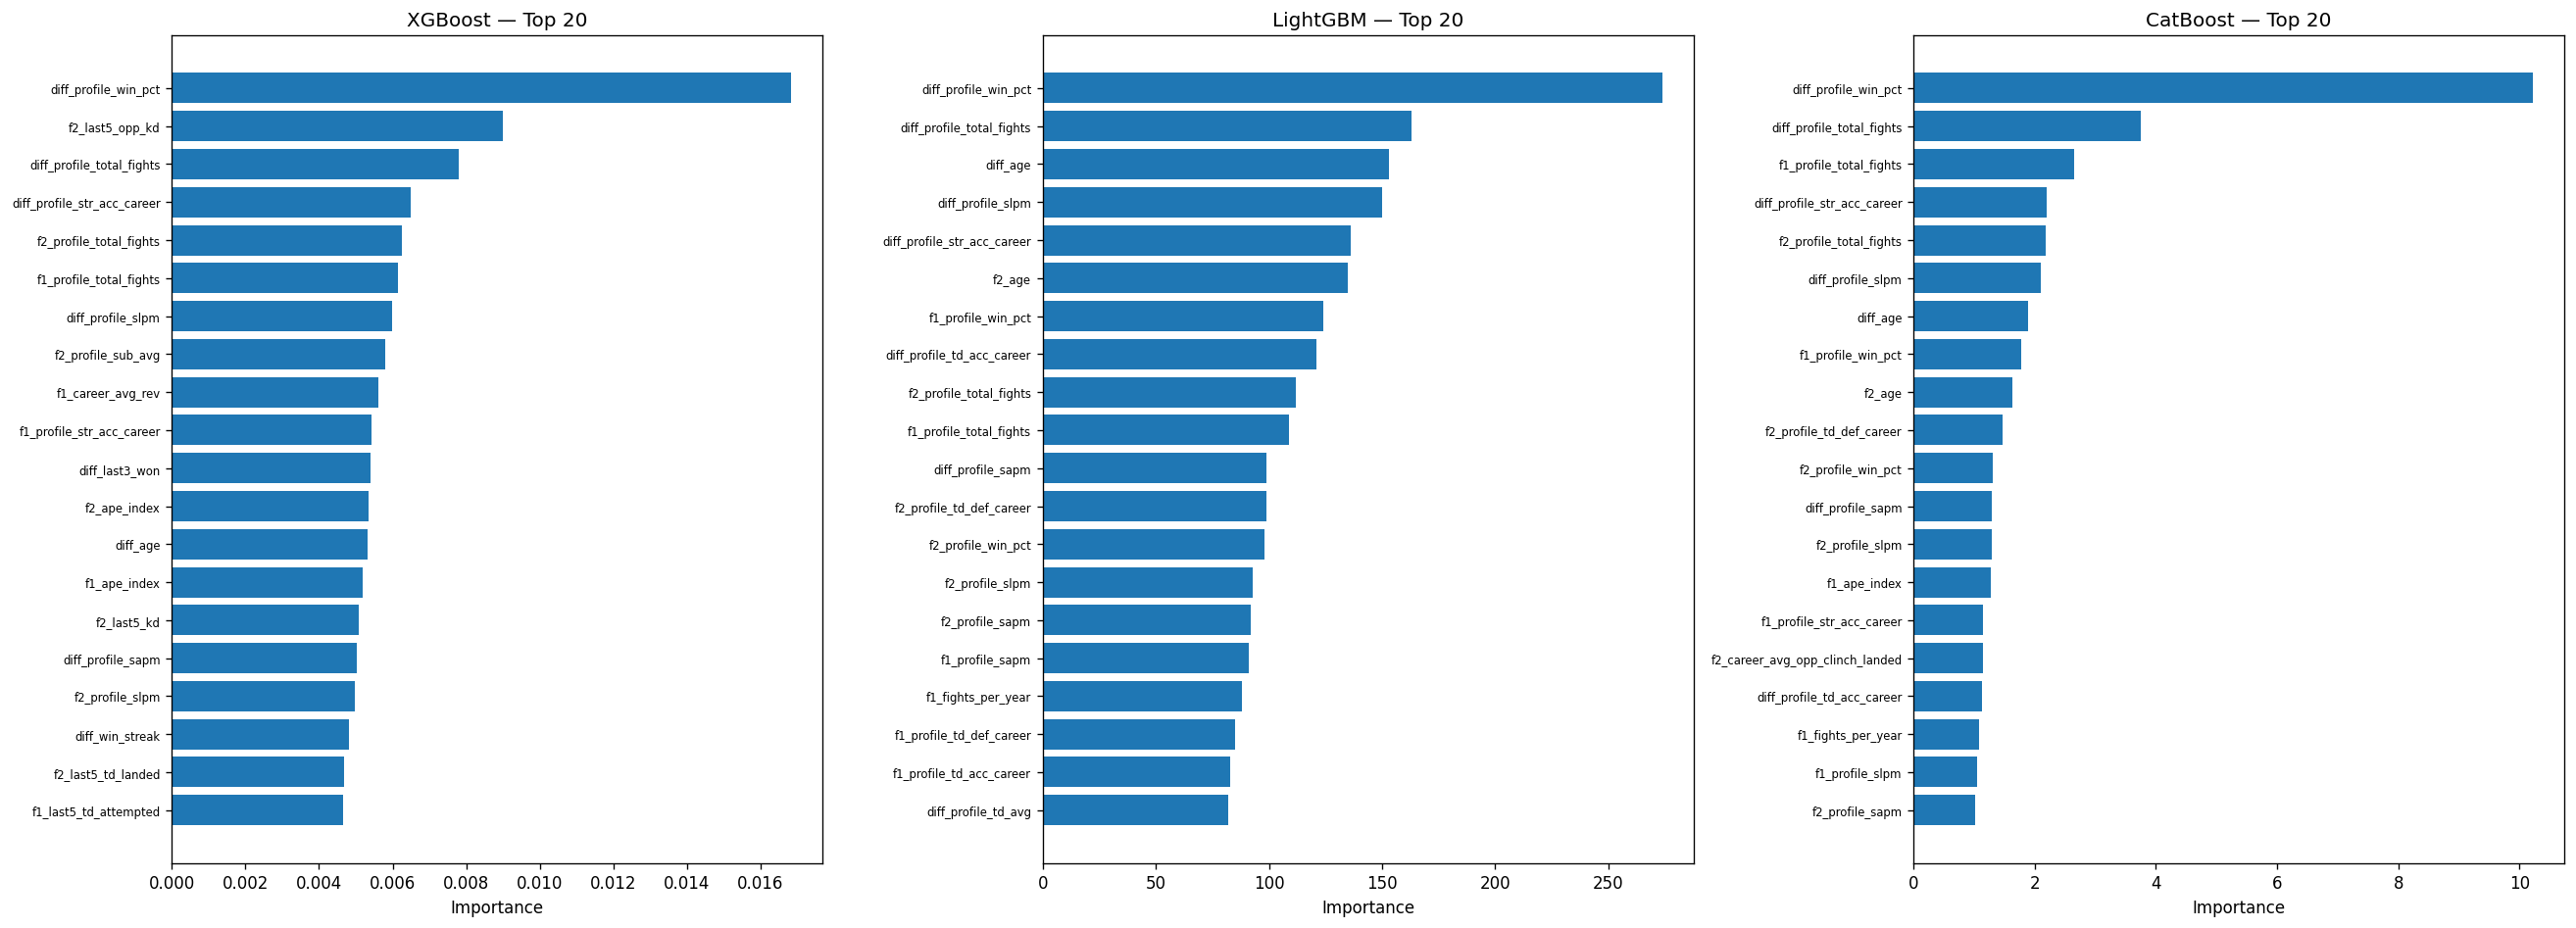

Consensus Top 15 (average rank across 3 models):
──────────────────────────────────────────────────
   1. diff_profile_win_pct                          [1/1/1]  PROFILE
   2. diff_profile_total_fights                     [3/2/2]  PROFILE
   3. diff_profile_str_acc_career                   [4/5/4]  PROFILE
   4. diff_profile_slpm                             [7/4/6]  PROFILE
   5. f1_profile_total_fights                       [6/10/3]  PROFILE
   6. f2_profile_total_fights                       [5/9/5]  PROFILE
   7. diff_age                                      [13/3/7]  PHYSICAL
   8. f2_age                                        [22/6/9]  PHYSICAL
   9. diff_profile_sapm                             [16/12/12]  PROFILE
  10. f1_profile_win_pct                            [26/7/8]  PROFILE
  11. f2_profile_slpm                               [17/14/13]  PROFILE
  12. f1_profile_str_acc_career                     [10/23/15]  PROFILE
  13. f2_profile_td_def_career                      [28/1

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

importance_data = {}

for idx, (name, mtype) in enumerate([('XGBoost', 'xgb'), ('LightGBM', 'lgb'), ('CatBoost', 'cat')]):
    model = all_results[name]['model']
    imp = model.feature_importances_

    imp_df = pd.DataFrame({'feature': feature_cols, 'importance': imp})
    imp_df = imp_df.sort_values('importance', ascending=False)
    importance_data[name] = imp_df

    top20 = imp_df.head(20)
    ax = axes[idx]
    ax.barh(range(20), top20['importance'].values[::-1])
    ax.set_yticks(range(20))
    ax.set_yticklabels(top20['feature'].values[::-1], fontsize=7)
    ax.set_title(f'{name} — Top 20')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig(DATA / 'feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Consensus ranking ──
rank_df = pd.DataFrame({'feature': feature_cols})
for name, imp_df in importance_data.items():
    merged = imp_df.copy()
    merged['rank'] = merged['importance'].rank(ascending=False)
    rank_df = rank_df.merge(merged[['feature', 'rank']], on='feature', suffixes=('', f'_{name}'))
    rank_df = rank_df.rename(columns={'rank': f'rank_{name}'})

rank_cols = [c for c in rank_df.columns if c.startswith('rank_')]
rank_df['avg_rank'] = rank_df[rank_cols].mean(axis=1)
rank_df = rank_df.sort_values('avg_rank')

print("Consensus Top 15 (average rank across 3 models):")
print("─" * 50)
for i, (_, row) in enumerate(rank_df.head(15).iterrows()):
    feat = row['feature']
    ranks = [f"{row[c]:.0f}" for c in rank_cols]
    ftype = ('PROFILE' if 'profile' in feat else
             'PHYSICAL' if any(x in feat for x in ['age', 'height', 'reach', 'ape', 'weight_lbs']) else
             'CAREER' if 'career' in feat else
             'LAST-3' if 'last3' in feat else
             'LAST-5' if 'last5' in feat else
             'ACTIVITY' if any(x in feat for x in ['streak', 'days_since', 'fights_per']) else
             'OTHER')
    print(f"  {i+1:>2}. {feat:<45s} [{'/'.join(ranks)}]  {ftype}")

## Ablation Study

Which feature groups drive performance? Test LightGBM with different subsets
to understand the contribution of profile features, rolling features, and differentials.

In [ ]:
def quick_eval(features, label):
    """Train LightGBM on feature subset, return test metrics."""
    if len(features) == 0:
        return {'label': label, 'n_feats': 0, 'acc': baseline_acc, 'auc': 0.5, 'll': baseline_ll}

    model = LGBMClassifier(**lgb_params)
    model.fit(X_train[features], y_train)
    y_prob = model.predict_proba(X_test[features])[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        'label': label,
        'n_feats': len(features),
        'acc': accuracy_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob),
        'll': log_loss(y_test, y_prob),
    }

# Define feature subsets
all_feats     = feature_cols
diff_feats    = [c for c in feature_cols if c.startswith('diff_')]
profile_feats = [c for c in feature_cols if 'profile' in c]
no_profile    = [c for c in feature_cols if 'profile' not in c]
diff_no_prof  = [c for c in diff_feats if 'profile' not in c]
diff_prof     = [c for c in diff_feats if 'profile' in c]

career_feats  = [c for c in feature_cols if 'career' in c and 'profile' not in c]
recent_feats  = [c for c in feature_cols if any(x in c for x in ['last3', 'last5'])]
physical_feats = [c for c in feature_cols if any(x in c for x in ['age', 'height', 'reach', 'ape', 'weight_lbs',
                                                                     'streak', 'days_since', 'fights_per',
                                                                     'weight_class', 'stance'])]

ablation_sets = [
    (all_feats,      "All features"),
    (no_profile,     "All − profile"),
    (diff_feats,     "Diffs only"),
    (diff_no_prof,   "Diffs − profile"),
    (profile_feats,  "Profile only"),
    (diff_prof,      "Profile diffs only"),
    (career_feats,   "Career rolling only"),
    (recent_feats,   "Recent form only (L3+L5)"),
    (physical_feats, "Physical + activity + categoricals"),
]

ablation_results = [quick_eval(feats, label) for feats, label in ablation_sets]
abl_df = pd.DataFrame(ablation_results)

print("ABLATION STUDY (LightGBM, default params)")
print("=" * 85)
print(f"{'Feature Set':<38} {'#Feats':>7} {'Acc':>7} {'AUC':>7} {'LL':>7} {'Lift':>7}")
print("─" * 85)
for _, row in abl_df.iterrows():
    lift = row['acc'] - baseline_acc
    print(f"{row['label']:<38} {row['n_feats']:>7} {row['acc']:>7.3f} {row['auc']:>7.3f} "
          f"{row['ll']:>7.3f} {lift:>+7.3f}")

# Key takeaways
all_acc = abl_df.loc[abl_df['label'] == 'All features', 'acc'].values[0]
no_prof_acc = abl_df.loc[abl_df['label'] == 'All − profile', 'acc'].values[0]
prof_only_acc = abl_df.loc[abl_df['label'] == 'Profile only', 'acc'].values[0]
diff_acc = abl_df.loc[abl_df['label'] == 'Diffs only', 'acc'].values[0]

print(f"\nKey findings:")
print(f"  Profile impact:    {all_acc - no_prof_acc:+.3f} (All − No profile)")
print(f"  Profile alone:     {prof_only_acc:.3f} ({prof_only_acc - baseline_acc:+.3f} vs baseline)")
print(f"  Diffs compression: {diff_acc:.3f} with {len(diff_feats)} feats vs {all_acc:.3f} with {len(all_feats)} feats")
print(f"  Rolling alone:     {abl_df.loc[abl_df['label'] == 'Career rolling only', 'acc'].values[0]:.3f}")

ABLATION STUDY (LightGBM, default params)
Feature Set                             #Feats     Acc     AUC      LL    Lift
─────────────────────────────────────────────────────────────────────────────────────
All features                               310   0.781   0.868   0.452  +0.227
All − profile                              280   0.625   0.657   0.658  +0.071
Diffs only                                 101   0.783   0.855   0.469  +0.230
Diffs − profile                             91   0.635   0.664   0.655  +0.082
Profile only                                30   0.770   0.857   0.472  +0.217
Profile diffs only                          10   0.755   0.846   0.478  +0.202
Career rolling only                        134   0.582   0.562   0.718  +0.028
Recent form only (L3+L5)                   111   0.599   0.593   0.702  +0.046
Physical + activity + categoricals          45   0.594   0.627   0.686  +0.041

Key findings:
  Profile impact:    +0.156 (All − No profile)
  Profile alone:    

## Calibration Analysis

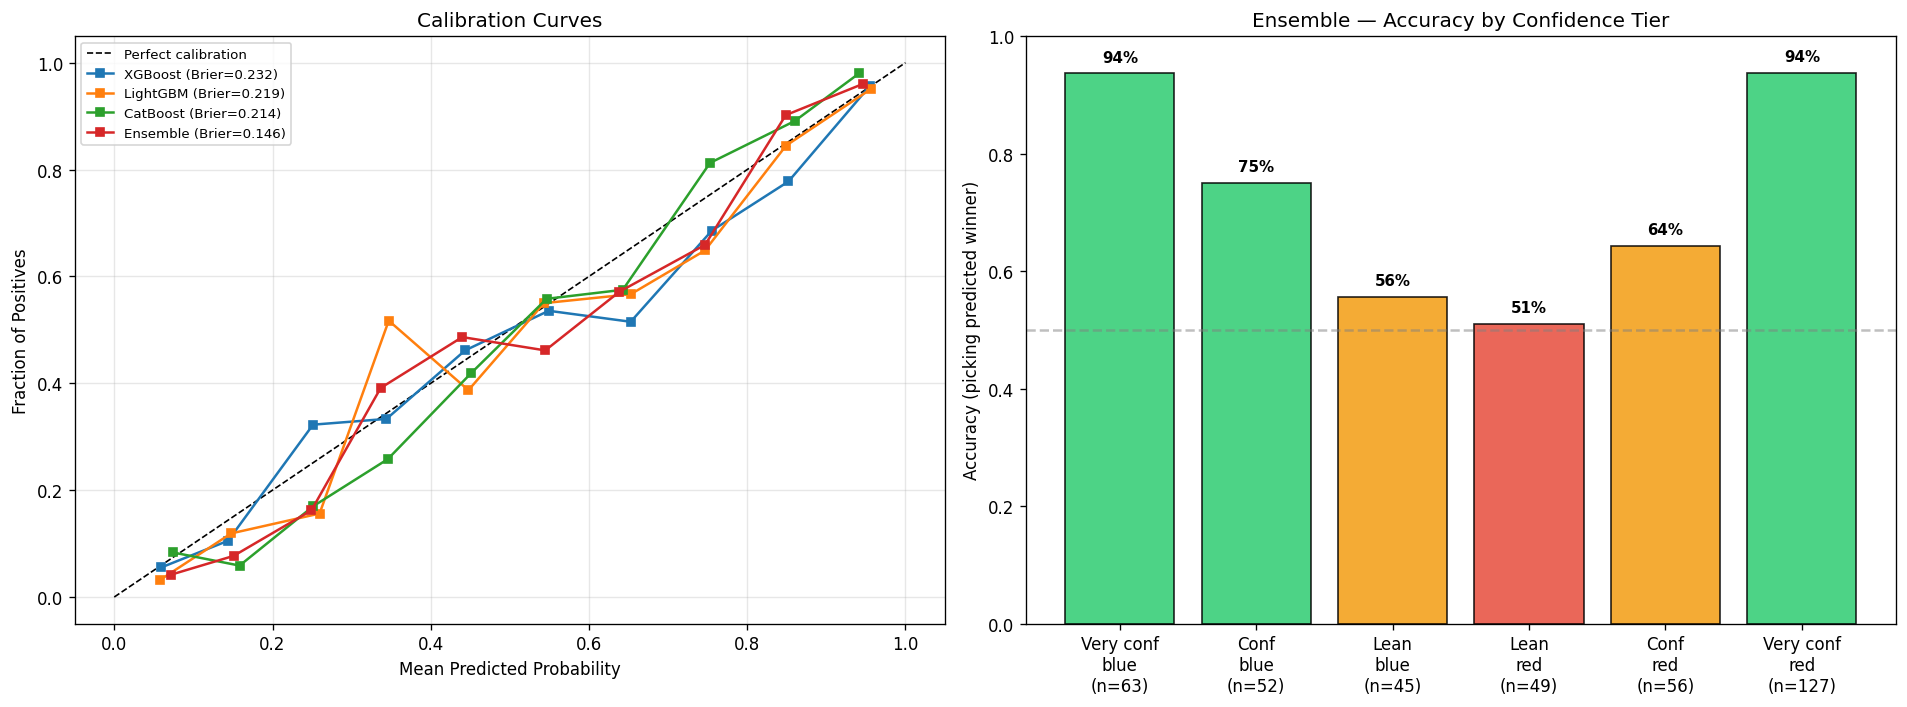

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Calibration curves ──
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')

for name in ['XGBoost', 'LightGBM', 'CatBoost', 'Ensemble']:
    prob = all_results[name]['y_prob']
    brier = all_results[name]['test']['brier']
    prob_true, prob_pred = calibration_curve(y_test, prob, n_bins=10, strategy='uniform')
    ax.plot(prob_pred, prob_true, 's-', label=f"{name} (Brier={brier:.3f})", markersize=5)

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Confidence tier accuracy ──
ax = axes[1]

buckets = [
    (0.0,  0.20, 'Very conf\nblue'),
    (0.20, 0.35, 'Conf\nblue'),
    (0.35, 0.50, 'Lean\nblue'),
    (0.50, 0.65, 'Lean\nred'),
    (0.65, 0.80, 'Conf\nred'),
    (0.80, 1.01, 'Very conf\nred'),
]

labels, accs, counts = [], [], []
for lo, hi, label in buckets:
    mask = (ens_prob >= lo) & (ens_prob < hi)
    n = mask.sum()
    if n > 0:
        if lo < 0.5:
            acc = 1 - y_test[mask].mean()  # blue predicted, so accuracy = blue win rate
        else:
            acc = y_test[mask].mean()  # red predicted, so accuracy = red win rate
        labels.append(f"{label}\n(n={n})")
        accs.append(acc)
        counts.append(n)

colors = ['#e74c3c' if a < 0.55 else '#f39c12' if a < 0.65 else '#27ae60' if a < 0.75 else '#2ecc71'
          for a in accs]
bars = ax.bar(labels, accs, color=colors, edgecolor='black', alpha=0.85)
ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
ax.set_ylabel('Accuracy (picking predicted winner)')
ax.set_title('Ensemble — Accuracy by Confidence Tier')
ax.set_ylim(0, 1.0)
for i, (a, n) in enumerate(zip(accs, counts)):
    ax.text(i, a + 0.02, f"{a:.0%}", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(DATA / 'calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Error Analysis

Where does the model fail? Examine confident wrong predictions, accuracy by
weight class, finish type, and over time.

In [ ]:
test_df = df.loc[test_mask].copy()
test_df['ens_prob'] = ens_prob
test_df['ens_pred'] = ens_pred
test_df['correct'] = (test_df['ens_pred'] == test_df['f1_win']).astype(int)
test_df['confidence'] = (test_df['ens_prob'] - 0.5).abs()

# ── Confident wrong predictions ──
print("CONFIDENT WRONG PREDICTIONS (>80% confidence)")
print("=" * 90)

conf_wrong = test_df[
    (test_df['correct'] == 0) &
    ((test_df['ens_prob'] > 0.80) | (test_df['ens_prob'] < 0.20))
].sort_values('confidence', ascending=False)

print(f"Total: {len(conf_wrong)} fights")
for _, row in conf_wrong.head(15).iterrows():
    prob = row['ens_prob']
    favored = row['fighter_1'] if prob >= 0.5 else row['fighter_2']
    actual  = row['fighter_1'] if row['f1_win'] == 1 else row['fighter_2']
    conf = max(prob, 1 - prob)
    print(f"  {row['event_date'].strftime('%Y-%m-%d')} | {row['fighter_1']} vs {row['fighter_2']:<25s} | "
          f"Pick: {favored:<25s} ({conf:.0%}) | Won: {actual}")

# ── By weight class ──
print(f"\n{'='*70}")
print("ACCURACY BY WEIGHT CLASS")
print(f"{'='*70}")
wc = test_df.groupby('weight_class').agg(
    n=('correct', 'count'),
    acc=('correct', 'mean'),
    base=('f1_win', 'mean'),
).sort_values('acc', ascending=False)
wc['lift'] = wc['acc'] - wc['base']

for wc_name, row in wc.iterrows():
    bar = '█' * int(row['acc'] * 30)
    print(f"  {wc_name:<28s} n={row['n']:>3.0f}  acc={row['acc']:.3f}  base={row['base']:.3f}  "
          f"lift={row['lift']:+.3f}  {bar}")

# ── By finish type ──
print(f"\n{'='*70}")
print("ACCURACY BY FINISH TYPE")
print(f"{'='*70}")
ft = test_df.groupby('finish_type').agg(
    n=('correct', 'count'),
    acc=('correct', 'mean'),
).sort_values('n', ascending=False)

for ft_name, row in ft.iterrows():
    print(f"  {ft_name:<12s} n={row['n']:>3.0f}  acc={row['acc']:.3f}")

# ── Over time ──
print(f"\n{'='*70}")
print("ACCURACY OVER TIME (monthly)")
print(f"{'='*70}")
test_df['month'] = test_df['event_date'].dt.to_period('M')
monthly = test_df.groupby('month').agg(
    n=('correct', 'count'),
    acc=('correct', 'mean'),
).reset_index()

for _, row in monthly.iterrows():
    bar = '█' * int(row['acc'] * 30)
    print(f"  {row['month']}  n={row['n']:>3.0f}  acc={row['acc']:.3f}  {bar}")

CONFIDENT WRONG PREDICTIONS (>80% confidence)
Total: 12 fights
  2026-04-04 | Azamat Bekoev vs Tresean Gore              | Pick: Azamat Bekoev             (95%) | Won: Tresean Gore
  2026-01-24 | Arnold Allen vs Jean Silva                | Pick: Arnold Allen              (95%) | Won: Jean Silva
  2026-04-11 | Azamat Murzakanov vs Paulo Costa               | Pick: Azamat Murzakanov         (92%) | Won: Paulo Costa
  2025-10-18 | Bruno Silva vs HyunSung Park             | Pick: HyunSung Park             (90%) | Won: Bruno Silva
  2026-03-28 | Alexa Grasso vs Maycee Barber             | Pick: Maycee Barber             (89%) | Won: Alexa Grasso
  2026-02-07 | Jailton Almeida vs Rizvan Kuniev             | Pick: Jailton Almeida           (88%) | Won: Rizvan Kuniev
  2025-10-04 | Magomed Ankalaev vs Alex Pereira              | Pick: Magomed Ankalaev          (87%) | Won: Alex Pereira
  2025-08-22 | Shi Ming vs Bruna Brasil              | Pick: Shi Ming                  (85%) | Won: Bruna Bra

## Confusion Matrices

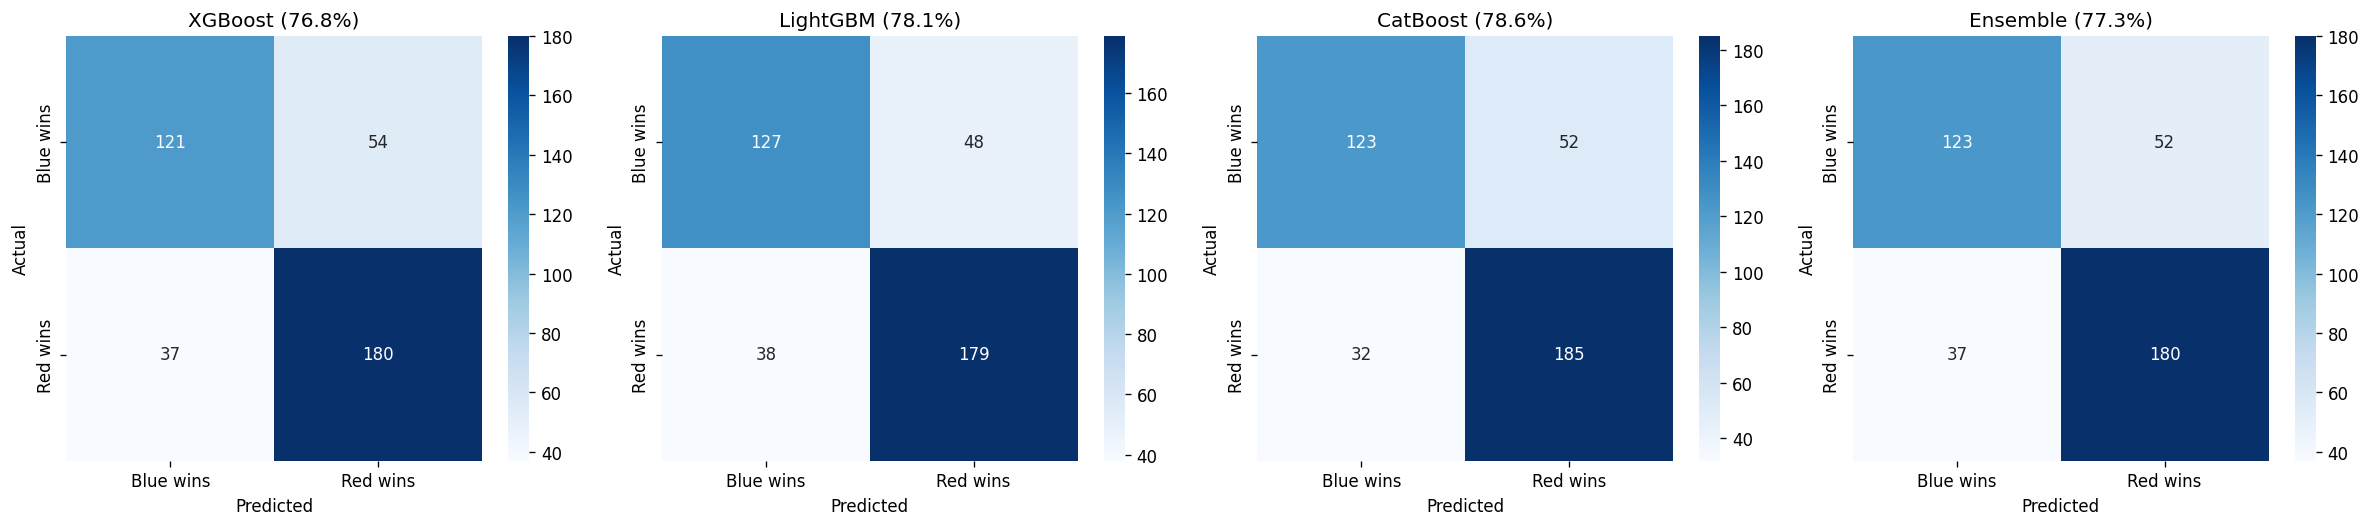


Ensemble Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.77      0.70      0.73       175
    Red wins       0.78      0.83      0.80       217

    accuracy                           0.77       392
   macro avg       0.77      0.77      0.77       392
weighted avg       0.77      0.77      0.77       392



In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for idx, name in enumerate(['XGBoost', 'LightGBM', 'CatBoost', 'Ensemble']):
    y_pred_m = all_results[name]['y_pred']
    cm = confusion_matrix(y_test, y_pred_m)

    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Blue wins', 'Red wins'],
                yticklabels=['Blue wins', 'Red wins'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    acc = all_results[name]['test']['acc']
    ax.set_title(f'{name} ({acc:.1%})')

plt.tight_layout()
plt.savefig(DATA / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification report for ensemble
print("\nEnsemble Classification Report:")
print(classification_report(y_test, ens_pred, target_names=['Blue wins', 'Red wins']))

## Probability Distributions

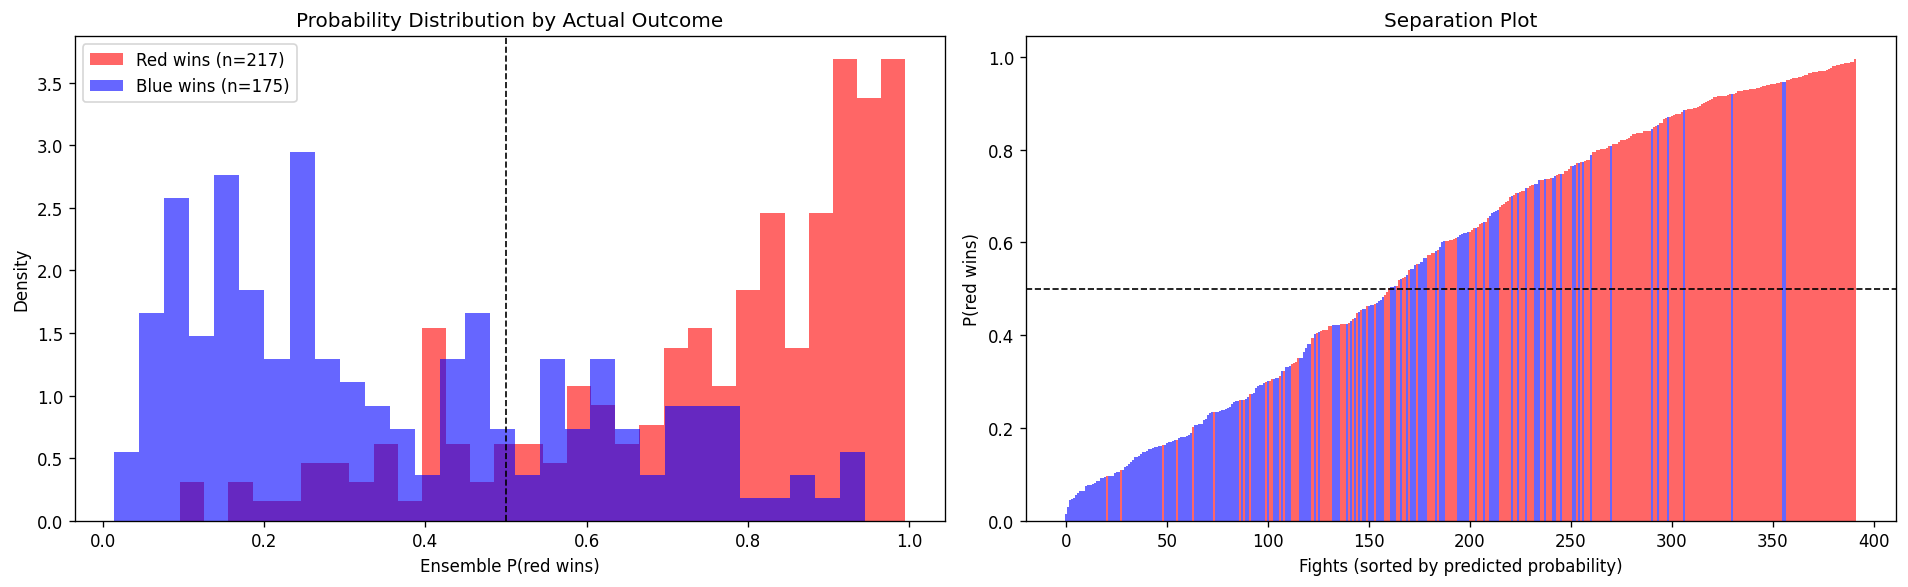

Probability distribution stats:
  Mean: 0.575  Std: 0.299
  Min: 0.014  Max: 0.995
  <40%: 31.4%  |  40-60%: 16.1%  |  >60%: 52.6%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Histogram by outcome ──
ax = axes[0]
red_probs = ens_prob[y_test == 1]
blue_probs = ens_prob[y_test == 0]

ax.hist(red_probs, bins=30, alpha=0.6, color='red', label=f'Red wins (n={len(red_probs)})', density=True)
ax.hist(blue_probs, bins=30, alpha=0.6, color='blue', label=f'Blue wins (n={len(blue_probs)})', density=True)
ax.axvline(0.5, color='black', ls='--', lw=1)
ax.set_xlabel('Ensemble P(red wins)')
ax.set_ylabel('Density')
ax.set_title('Probability Distribution by Actual Outcome')
ax.legend()

# ── Separation ──
ax = axes[1]
sorted_idx = np.argsort(ens_prob)
colors = ['red' if y_test.iloc[i] == 1 else 'blue' for i in sorted_idx]
ax.bar(range(len(ens_prob)), ens_prob[sorted_idx], color=colors, width=1.0, alpha=0.6)
ax.axhline(0.5, color='black', ls='--', lw=1)
ax.set_xlabel('Fights (sorted by predicted probability)')
ax.set_ylabel('P(red wins)')
ax.set_title('Separation Plot')

plt.tight_layout()
plt.savefig(DATA / 'probability_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
print(f"Probability distribution stats:")
print(f"  Mean: {ens_prob.mean():.3f}  Std: {ens_prob.std():.3f}")
print(f"  Min: {ens_prob.min():.3f}  Max: {ens_prob.max():.3f}")
print(f"  <40%: {(ens_prob < 0.4).mean():.1%}  |  40-60%: {((ens_prob >= 0.4) & (ens_prob < 0.6)).mean():.1%}  |  >60%: {(ens_prob >= 0.6).mean():.1%}")

## Save Models, Predictions & Summary

In [ ]:
# ── Save models (native formats) ──
all_results['XGBoost']['model'].save_model(str(MODEL_DIR / 'xgb_baseline.json'))
all_results['LightGBM']['model'].booster_.save_model(str(MODEL_DIR / 'lgb_baseline.txt'))
all_results['CatBoost']['model'].save_model(str(MODEL_DIR / 'cat_baseline.cbm'))
# ── Save predictions ──
pred_df = df.loc[test_mask, ['event_name', 'event_date', 'fighter_1', 'fighter_2',
                              'weight_class', 'f1_win', 'finish_type']].copy()
pred_df['xgb_prob'] = all_results['XGBoost']['y_prob']
pred_df['lgb_prob'] = all_results['LightGBM']['y_prob']
pred_df['cat_prob'] = all_results['CatBoost']['y_prob']
pred_df['ens_prob'] = ens_prob
pred_df['ens_pred'] = ens_pred
pred_df['correct']  = (ens_pred == y_test.values).astype(int)
pred_df.to_csv(DATA / 'test_predictions.csv', index=False)

# ── Save feature list ──
with open(DATA / 'feature_list.txt', 'w') as f:
    for feat in feature_cols:
        f.write(feat + '\n')

# ── Save default params for NB06 comparison ──
default_params = {
    'XGBoost': xgb_params,
    'LightGBM': lgb_params,
    'CatBoost': cat_params,
}
with open(DATA / 'default_params.json', 'w') as f:
    json.dump(default_params, f, indent=2)

# ── Save NB05 results for NB06 comparison ──
nb05_results = {}
for name in ['XGBoost', 'LightGBM', 'CatBoost', 'Ensemble']:
    nb05_results[name] = all_results[name]['test']
with open(DATA / 'nb05_results.json', 'w') as f:
    json.dump(nb05_results, f, indent=2)

print("Saved:")
print(f"  Models:       {MODEL_DIR}/xgb_baseline.json, lgb_baseline.txt, cat_baseline.cbm")
print(f"  Predictions:  {DATA}/test_predictions.csv ({len(pred_df)} rows)")
print(f"  Features:     {DATA}/feature_list.txt ({len(feature_cols)} features)")
print(f"  Default params: {DATA}/default_params.json")
print(f"  NB05 results: {DATA}/nb05_results.json")

# ── Final summary ──
print("\n" + "=" * 70)
print("NOTEBOOK 05 — FINAL SUMMARY")
print("=" * 70)
print(f"Split: train < {SPLIT_DATE} ({len(X_train):,} fights) | test ≥ {SPLIT_DATE} ({len(X_test):,} fights)")
print(f"Features: {len(feature_cols)}")
print(f"Baseline (always red): {baseline_acc:.3f}")
print()
print(f"{'Model':<12} {'Test Acc':>9} {'Lift':>8} {'AUC':>8} {'LogLoss':>9} {'Brier':>8}")
print("─" * 70)
for name in ['XGBoost', 'LightGBM', 'CatBoost', 'Ensemble']:
    t = all_results[name]['test']
    lift = t['acc'] - baseline_acc
    print(f"{name:<12} {t['acc']:>9.3f} {lift:>+8.3f} {t['auc']:>8.3f} {t['ll']:>9.3f} {t['brier']:>8.3f}")
print()
print("These are DEFAULT hyperparameter baselines.")
print("NB06 will tune hyperparameters and compare against these numbers on the SAME test set.")
print("=" * 70)

Saved:
  Models:       ../models/xgb_baseline.json, lgb_baseline.txt, cat_baseline.cbm
  Predictions:  data/test_predictions.csv (392 rows)
  Features:     data/feature_list.txt (310 features)
  Default params: data/default_params.json
  NB05 results: data/nb05_results.json

NOTEBOOK 05 — FINAL SUMMARY
Split: train < 2025-07-01 (5,093 fights) | test ≥ 2025-07-01 (392 fights)
Features: 310
Baseline (always red): 0.554

Model         Test Acc     Lift      AUC   LogLoss    Brier
──────────────────────────────────────────────────────────────────────
XGBoost          0.768   +0.214    0.864     0.458    0.232
LightGBM         0.781   +0.227    0.868     0.452    0.219
CatBoost         0.786   +0.232    0.872     0.457    0.214
Ensemble         0.773   +0.219    0.871     0.448    0.146

These are DEFAULT hyperparameter baselines.
NB06 will tune hyperparameters and compare against these numbers on the SAME test set.


In [ ]:
# ── Correlation Matrix: Top Features ──
# Grab top 30 features by consensus rank + target
top_feats = list(rank_df.head(30)['feature'].values)

corr_cols = top_feats + [target]
corr_matrix = df.loc[train_mask, corr_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, square=True,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 6},
    ax=ax,
)

ax.set_title('Correlation Matrix — Top 30 Features + Target (Training Set)', fontsize=14)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.savefig(DATA / 'correlation_matrix_top30.png', dpi=150, bbox_inches='tight')
plt.show()

# ── High correlation pairs (potential redundancy) ──
print("HIGH CORRELATION PAIRS (|r| > 0.80, excluding self)")
print("=" * 70)

pairs = []
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.80:
            pairs.append((corr_matrix.index[i], corr_matrix.columns[j], r))

pairs.sort(key=lambda x: -abs(x[2]))

if pairs:
    for f1, f2, r in pairs:
        print(f"  {r:+.3f}  {f1}  ↔  {f2}")
else:
    print("  None found — top features are reasonably independent")

# ── Target correlations ──
print(f"\nTOP 30 FEATURES — CORRELATION WITH {target}")
print("─" * 55)
target_corr = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)
for feat, r in target_corr.items():
    bar = '█' * int(abs(r) * 40)
    sign = '+' if r > 0 else '-'
    print(f"  {sign}{abs(r):.3f}  {feat:<45s} {bar}")

NameError: name 'rank_df' is not defined